In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pickle
from scipy.spatial import ConvexHull, Delaunay
from scipy.stats import mannwhitneyu
import numpy as np
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests
import squidpy as sq
import sys
from scipy.stats import fisher_exact
import tifffile as tf
from tqdm import tqdm
sys.path.append("../src")
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
from border_effects_kNN_del import trunc_graphs, get_mibitof, get_squidpy_visium_datasets

In [4]:
np.random.seed(41)

In [5]:
try:
    with open("/data/bionets/je30bery/truncated_graphs/mibitof_coords/coords.pickle", "rb") as f:
        datasets = pickle.load(f)
except FileNotFoundError:
    datasets = get_mibitof()
    datasets.update(get_squidpy_visium_datasets())
    with open("/data/bionets/je30bery/truncated_graphs/mibitof_coords/coords.pickle", "wb") as f:
        pickle.dump(datasets, f)

In [6]:
try:
    all_results = pd.read_csv("/data/bionets/je30bery/truncated_graphs/results/figure1/kNN_trunc.csv")
except:
    dfs = list()
    ks = [5, 10, 15]
    for square_limits in [(1/8, 7/8)]:
        for k in ks:
            df = pd.DataFrame(columns=["data_source", "#nodes in ROI", "node density in ROI", "% new edges", "P_MWU", "P_fisher", "border_size", "k", "img_size"])
            for dataset in tqdm(datasets):
                coords = datasets[dataset]
                width = np.max(coords[:, 0]) - np.min(coords[:, 0])
                height = np.max(coords[:, 1]) - np.min(coords[:, 1])
                assert width > 0 and height > 0, f"problem, {width}, {height}"
                    
                
                xlim = (np.min(coords[:, 0]) + width * square_limits[0], np.min(coords[:, 0]) + width * square_limits[1])
                ylim = (np.min(coords[:, 1]) + height * square_limits[0], np.min(coords[:, 1]) + height * square_limits[1]) 
        
                try:
                    out = trunc_graphs(coords=coords, return_graphs=False, method="kNN", xlim=xlim, ylim=ylim, k=k)
                    edge_df = out["edge_df"]
                
                    old = edge_df.loc[~edge_df["New edge"], "Edge length"]
                    new = edge_df.loc[edge_df["New edge"], "Edge length"]
                
                    p_mwu = mannwhitneyu(
                        old,
                        new,
                        alternative="two-sided"
                    ).pvalue
    
                    contingency = pd.crosstab(edge_df["New edge"], edge_df["Symmetry"])
                    values = np.array([[contingency.loc[True, False], contingency.loc[True, True]],
                                              [contingency.loc[False, False], contingency.loc[False, True]]])
                    _, p_fisher = fisher_exact(values, alternative="greater")
    
                    data_source = dataset.split(":")[0]
                    df.loc[dataset] = [data_source, out["#nodes in ROI"], out["#nodes in ROI"] / (float(height) * float(width)), len(new) / (len(new) + len(old)), p_mwu, p_fisher, square_limits[0], k, (height, width)]
                except: # if too few cells are within ROI
                    continue
            dfs.append(df)
    all_results = pd.concat(dfs)
    all_results["% new edges"] *= 100
    _, all_results["P_MWU_adj"], _, _ = multipletests(all_results["P_MWU"], alpha=0.05, method="fdr_bh")
    _, all_results["P_fisher_adj"], _, _ = multipletests(all_results["P_fisher"], alpha=0.05, method="fdr_bh")
    all_results.to_csv("/data/bionets/je30bery/truncated_graphs/results/figure1/kNN_trunc.csv")

In [7]:
square_limits = (1/8, 7/8)
coords = datasets['glioma_mibitof:Brainiaqc_R1C1_whole_cell.tiff']
width = np.max(coords[:, 0]) - np.min(coords[:, 0])
height = np.max(coords[:, 1]) - np.min(coords[:, 1])

xlim = (np.min(coords[:, 0]) + width * square_limits[0], np.min(coords[:, 0]) + width * square_limits[1])
ylim = (np.min(coords[:, 1]) + height * square_limits[0], np.min(coords[:, 1]) + height * square_limits[1]) 

out = trunc_graphs(coords=coords, return_graphs=True, method="kNN", xlim=xlim, ylim=ylim, k=5)

coords = out["coords"]
subset = out["subset"]

G = out["G"]
subG = out["subG"]
plotG = out["plotG"]
truncG = out["truncG"]

edge_df = out["edge_df"]

In [8]:
p = mannwhitneyu(
    edge_df.loc[~edge_df["New edge"], "Edge length"],
    edge_df.loc[edge_df["New edge"], "Edge length"],
    alternative="two-sided"
).pvalue

In [9]:
ori = edge_df["New edge"].value_counts()[False]
new = len(edge_df) - ori
print(len(truncG.nodes))
print(ori, new, p)

480
2270 130 2.5561361208284283e-36


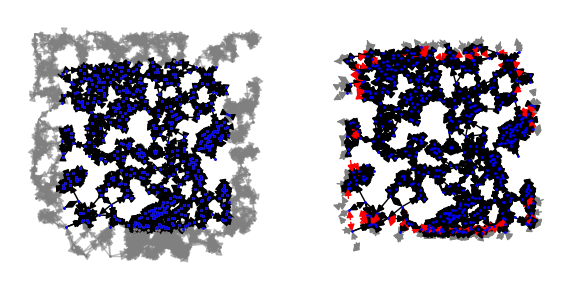

In [10]:
f, axs = plt.subplots(1, 2, figsize=(6, 3))

nx.draw(G, pos=coords, edge_color=(0.5, 0.5, 0.5, 0.5), node_size=1, node_color="gray", ax=axs[0])
nx.draw(subG, node_size=1, pos=coords, node_color="blue", ax=axs[0])

nx.draw_networkx_edges(plotG, pos=coords, ax=axs[1], edge_color="gray")
nx.draw(subG, node_size=1, pos=coords, ax=axs[1], node_color="blue")

edge_colors = [edge in G.edges for edge in truncG.edges]
nx.draw_networkx_edges(truncG, pos=coords, ax=axs[1], edge_color=np.where(edge_colors, "black", "red")) #, node_color=subcoords[:, 2], cmap="magma", vmin=-1, vmax=1)

for ax in axs:
    ax.set_aspect('equal')

plt.tight_layout()
#plt.savefig("../result_plots/fig2/delaunay_trunc_1.svg")

<Axes: ylabel='Edge length'>

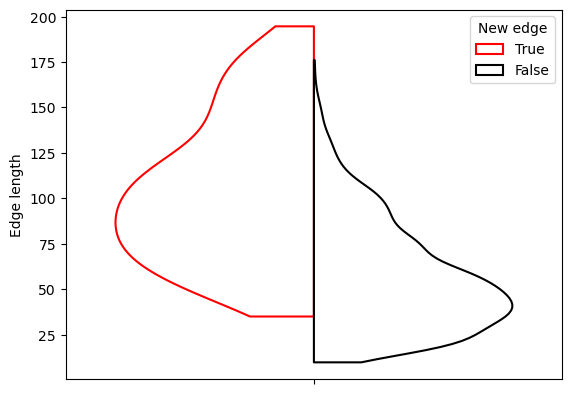

In [11]:
sns.violinplot(edge_df, y="Edge length", hue="New edge", cut=0, fill=False, split=True, palette={False: "black", True: "red"}, hue_order=[True, False], inner=None)

In [12]:
sources = sorted(list(all_results["data_source"].unique()))
palette = dict(zip(sources, sns.color_palette("magma", len(sources))))

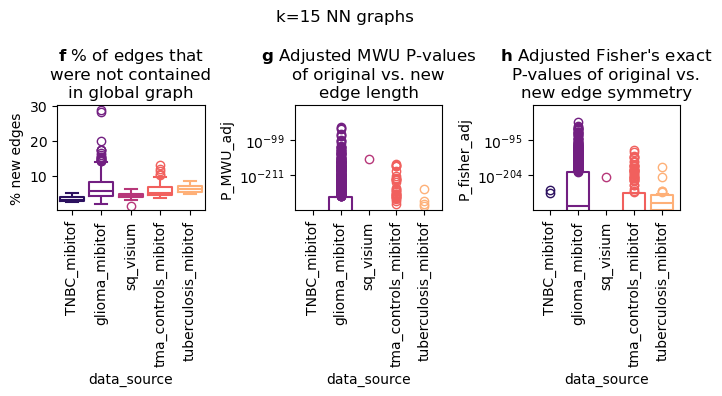

In [13]:
f, axs = plt.subplots(1, 3, figsize=(7, 4))
sns.boxplot(all_results[all_results["k"] == 15], x="data_source", y="% new edges", ax=axs[0], hue="data_source", legend=False, palette=palette, order=sources, fill=False)
sns.boxplot(all_results[all_results["k"] == 15], x="data_source", y="P_MWU_adj", ax=axs[1], hue="data_source", legend=False, palette=palette, order=sources, fill=False)
sns.boxplot(all_results[all_results["k"] == 15], x="data_source", y="P_fisher_adj", ax=axs[2], hue="data_source", legend=False, palette=palette, order=sources, fill=False)

axs[1].hlines(0.001, xmin=0, xmax=all_results["node density in ROI"].max(), color="gray")
axs[1].set_yscale("log")
axs[2].hlines(0.001, xmin=0, xmax=all_results["node density in ROI"].max(), color="gray")
axs[2].set_yscale("log")

f.suptitle("k=15 NN graphs")
axs[0].set_title("$\\mathbf{f}$ % of edges that\nwere not contained\nin global graph")
axs[1].set_title("$\\mathbf{g}$ Adjusted MWU P-values\nof original vs. new\nedge length")
axs[2].set_title("$\\mathbf{h}$ Adjusted Fisher's exact\nP-values of original vs.\nnew edge symmetry")

axs[0].tick_params(axis='x', labelrotation=90)
axs[1].tick_params(axis='x', labelrotation=90)
axs[2].tick_params(axis='x', labelrotation=90)

plt.tight_layout()

plt.savefig("../result_plots/kNN_trunc.pdf")

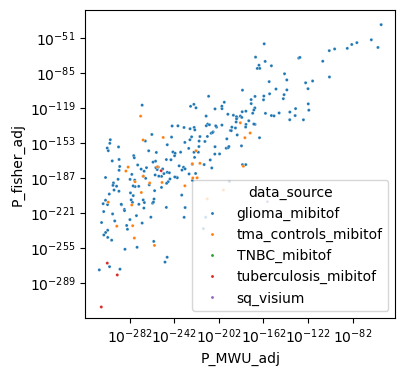

In [14]:
f, ax = plt.subplots(1, figsize=(4,4))
sns.scatterplot(all_results[all_results["k"] == 15], x="P_MWU_adj", y="P_fisher_adj", s=5, hue="data_source", ax=ax)
ax.set_yscale("log")
ax.set_xscale("log")
plt.savefig("../result_plots/kNN_supp.pdf")

In [15]:
len(all_results) / 3

1041.0